<a href="https://colab.research.google.com/github/NadiiaIvashchuk/melbourne-housing-project/blob/main/notebooks/melbourne_housing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Project

## Підготовка даних

In [317]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

FILE_IN = 'https://raw.githubusercontent.com/NadiiaIvashchuk/melbourne-housing-project/refs/heads/main/data/melb_data.csv'
df_origin = pd.read_csv(FILE_IN)
df = df_origin.copy()

print("Ринок нерухомості в Мельбурні:", df.shape)
df.head()

Ринок нерухомості в Мельбурні: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [318]:
pd.read_csv('https://raw.githubusercontent.com/NadiiaIvashchuk/melbourne-housing-project/refs/heads/main/data/melb_data.csv')

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,4.0,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,3.0,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,3.0,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,4.0,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


## First review of data set

In [319]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [320]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Car,62,0.5
BuildingArea,6450,47.5
YearBuilt,5375,39.6
CouncilArea,1369,10.1


In [321]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [322]:
info = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропусків_%": (df.isna().mean() * 100).round(1),
})
print(info.sort_values("пропусків_%", ascending=False))
df.describe()

                   тип  пропусків_%
BuildingArea   float64         47.5
YearBuilt      float64         39.6
CouncilArea     object         10.1
Car            float64          0.5
Suburb          object          0.0
Price          float64          0.0
Type            object          0.0
Rooms            int64          0.0
Address         object          0.0
Distance       float64          0.0
Method          object          0.0
Date            object          0.0
SellerG         object          0.0
Bathroom       float64          0.0
Bedroom2       float64          0.0
Postcode       float64          0.0
Landsize       float64          0.0
Lattitude      float64          0.0
Longtitude     float64          0.0
Regionname      object          0.0
Propertycount  float64          0.0


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


## Cleaning

In [323]:
clean = df.copy()
clean.columns = clean.columns.str.strip()
clean = clean.rename(columns={
    'Suburb': 'suburb',
    'Address': 'address',
    'Rooms': 'cnt_rooms',
    'Type': 'type',
    'Price': 'price',
    'Method': 'method',
    'SellerG': 'seller',
    'Date': 'date',
    'Distance': 'distance',
    'Postcode': 'postcode',
    'Bedroom2': 'bedroom',
    'Bathroom': 'bathroom',
    'Car': 'cnt_carpots',
    'Landsize': 'landsize',
    'BuildingArea': 'build_area',
    'YearBuilt': 'year_built',
    'CouncilArea': 'gov_area',
    'Lattitude': 'lattitude',
    'Longtitude': 'longtitude',
    'Regionname': 'region',
    'Propertycount': 'propertycount'
})



clean['date'] = pd.to_datetime(clean['date'], dayfirst=True, errors='coerce')

clean.head()


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [341]:
display(clean.loc[clean['year_built'] > clean['date'].dt.year])

clean.loc[clean['year_built'] > clean['date'].dt.year, 'year_built']= np.nan



,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
426,Avondale Heights,157 Canning St,3,t,851000.0,S,Nelson,2016-12-03,10.5,3034,3,3,1,557.0,181.0,2017,Moonee Valley,-37.7700,144.8572,Western Metropolitan,4502
3386,Keilor East,20 Keith Gr,3,h,825000.0,S,Nelson,2016-04-23,12.8,3033,3,2,1,630.0,126.0,2017,Moonee Valley,-37.7378,144.8705,Western Metropolitan,5629
5019,Reservoir,89 Darebin Bvd,4,h,767500.0,S,Barry,2016-09-17,11.2,3073,3,2,2,834.0,129.0,2017,Darebin,-37.7040,145.0299,Northern Metropolitan,21650


In [326]:
print(f"Sum of '0' value for build_area: {(clean['build_area']==0).sum()}")
clean.loc[clean['build_area'] == 0, 'build_area'] = np.nan


Sum of '0' value for build_area: 17


In [327]:
# Find unique value
clean['year_built'].sort_values().head(10)

#IQR
Q1 = clean['year_built'].quantile(0.25)
Q3 = clean['year_built'].quantile(0.75)
IQR = Q3 - Q1
reason_limit = Q1 - 1.5 * IQR
print(f"Reasonable limit for 'year_built': {reason_limit.astype(int)}")

# to Nan
clean.loc[clean['year_built'] < 1850, 'year_built'] = np.nan

clean['year_built'].sort_values().head(10)

Reasonable limit for 'year_built': 1851


,year_built
4843,1850.0
5405,1850.0
5860,1850.0
2554,1850.0
2530,1854.0
5536,1856.0
12158,1857.0
5543,1860.0
11503,1860.0
8583,1860.0


In [328]:
#clean = clean[clean['year_built']]

In [329]:
#check duplicate
clean.duplicated().sum()

np.int64(0)

In [330]:
#research rows with na value in build_area
build_na = clean[clean['build_area'].isna()]
fill_rows_rate = build_na.notna().mean().sort_values(ascending=False).to_frame('fill_rows_rate')
fill_rows_rate['fill_percent'] = fill_rows_rate['fill_rows_rate'] * 100

fill_rows_rate  # видаляти рядки недоцільно

,fill_rows_rate,fill_percent
suburb,1.000000,100.000000
address,1.000000,100.000000
cnt_rooms,1.000000,100.000000
type,1.000000,100.000000
price,1.000000,100.000000
method,1.000000,100.000000
seller,1.000000,100.000000
date,1.000000,100.000000
distance,1.000000,100.000000
postcode,1.000000,100.000000


In [331]:
clean.groupby(clean['build_area'].isna())['suburb'].describe()

,count,unique,top,freq
build_area,,,,
False,7113,303,Reservoir,174
True,6467,294,Reservoir,185


In [332]:
clean.groupby(clean['build_area'].isna())['date'].describe()

,count,mean,min,25%,50%,75%,max
build_area,,,,,,,
False,7113,2017-01-16 14:53:48.005061120,2016-02-04 00:00:00,2016-09-03 00:00:00,2016-12-10 00:00:00,2017-06-17 00:00:00,2017-09-23 00:00:00
True,6467,2017-02-11 07:15:32.426163712,2016-01-28 00:00:00,2016-09-17 00:00:00,2017-03-18 00:00:00,2017-07-01 00:00:00,2017-09-23 00:00:00


In [333]:
clean.groupby(clean['build_area'].isna())['type'].value_counts()

build_area  type
False       h       4846
            u       1584
            t        683
True        h       4603
            u       1433
            t        431
Name: count, dtype: int64

Для колонки build_area було проведено аналіз пропусків. Встановлено, що записи з відсутнім значенням містять майже повний набір інших характеристик. Додатково було порівняно розподіли ціни (price), площі ділянки (landsize), типу нерухомості (type), району (suburb) та дати продажу (date) між записами з наявним і відсутнім значенням build_area. Суттєвих відмінностей не виявлено, тому пропуски не демонструють очевидної систематичної закономірності. На етапі очищення даних було прийнято рішення не видаляти ці рядки і не імпутувати значення build_area. Остаточне рішення щодо використання цієї ознаки буде прийнято після оцінки її важливості під час побудови моделей.

In [334]:
# logical consistency check
print("Count bedroom > count rooms:")
display(clean[clean['bedroom'] > clean['cnt_rooms']])

print("Count bathroom > count rooms:")
display(clean[clean['bathroom'] > clean['cnt_rooms']])



Count bedroom > count rooms:


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,2016-05-07,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0
9,Abbotsford,10 Valiant St,2,h,1097000.0,S,Biggin,2016-10-08,2.5,3067.0,3.0,1.0,2.0,220.0,75.0,1900.0,Yarra,-37.80100,144.99890,Northern Metropolitan,4019.0
63,Airport West,6 Kittyhawk St,4,h,773000.0,S,Brad,2016-09-17,13.5,3042.0,5.0,3.0,4.0,531.0,309.0,1980.0,Moonee Valley,-37.72630,144.86790,Western Metropolitan,3464.0
207,Altona North,1/156 Chambers Rd,3,h,620000.0,SP,Hunter,2016-08-22,11.1,3025.0,5.0,2.0,2.0,276.0,100.0,2010.0,Hobsons Bay,-37.82620,144.84430,Western Metropolitan,5132.0
233,Armadale,11/17 Myamyn St,2,u,3625000.0,S,Jellis,2016-06-04,6.3,3143.0,3.0,2.0,2.0,0.0,NaN,2006.0,Stonnington,-37.85550,145.02910,Southern Metropolitan,4836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11536,Watsonia North,280 Grimshaw St,3,h,740000.0,SP,Barry,2017-07-15,14.5,3087.0,4.0,1.0,2.0,909.0,NaN,NaN,Banyule,-37.70255,145.08578,Northern Metropolitan,1442.0
11579,Aspendale,14 Ebb St,3,h,970000.0,VB,hockingstuart,2017-07-22,21.5,3195.0,4.0,2.0,2.0,612.0,154.0,1960.0,Kingston,-38.01596,145.09932,South-Eastern Metropolitan,2824.0
11846,Toorak,10/270 Williams Rd,1,u,350000.0,VB,Marshall,2017-07-22,4.1,3142.0,2.0,1.0,1.0,0.0,NaN,1970.0,Stonnington,-37.84157,145.00469,Southern Metropolitan,7217.0
12411,Thornbury,316 Rossmoyne St,3,h,1375000.0,S,McGrath,2017-09-03,7.0,3071.0,4.0,2.0,3.0,530.0,145.0,1950.0,NaN,-37.75968,145.02305,Northern Metropolitan,8870.0


Count bathroom > count rooms:


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
240,Armadale,10 William St,1,h,1435000.0,SP,Jellis,2016-10-08,6.3,3143.0,2.0,2.0,1.0,144.0,107.0,1900.0,Stonnington,-37.85640,145.02280,Southern Metropolitan,4836.0
446,Avondale Heights,6 Lovett Dr,4,h,1200000.0,S,Nelson,2016-06-04,10.5,3034.0,4.0,5.0,4.0,673.0,NaN,NaN,Moonee Valley,-37.75450,144.87360,Western Metropolitan,4502.0
557,Balwyn,49 Metung St,5,h,3400000.0,VB,Jellis,2016-06-18,9.7,3103.0,5.0,6.0,4.0,739.0,502.0,NaN,Boroondara,-37.80390,145.07140,Southern Metropolitan,5682.0
580,Balwyn,29 Sevenoaks St,5,h,3900000.0,PI,Jellis,2016-08-28,9.7,3103.0,5.0,7.0,6.0,0.0,NaN,NaN,Boroondara,-37.80490,145.07480,Southern Metropolitan,5682.0
1115,Brighton,89 South Rd,3,h,2020000.0,S,Nick,2016-09-17,11.2,3186.0,5.0,6.0,2.0,685.0,419.0,NaN,Bayside,-37.92840,144.99860,Southern Metropolitan,10579.0
1184,Brighton East,5 Margaret St,2,h,1780000.0,SP,Buxton,2016-05-07,10.7,3187.0,4.0,3.0,2.0,635.0,119.0,1935.0,Bayside,-37.92050,145.01020,Southern Metropolitan,6938.0
1234,Brighton East,8 Thomas St,2,h,1310000.0,S,Buxton,2016-09-24,10.7,3187.0,4.0,3.0,2.0,302.0,250.0,2018.0,Glen Eira,-37.91820,145.02310,Southern Metropolitan,6938.0
2029,Coburg,40 Elizabeth St,1,h,1007000.0,SP,Brad,2016-08-28,7.8,3058.0,1.0,2.0,0.0,807.0,1.0,NaN,Moreland,-37.73730,144.98250,Northern Metropolitan,11204.0
2560,Fitzroy North,186 Queens Pde,2,t,930000.0,S,Nelson,2016-09-03,3.5,3068.0,2.0,3.0,0.0,2778.0,3558.0,NaN,Yarra,-37.79030,144.98590,Northern Metropolitan,6244.0
2992,Hadfield,101 Middle St,2,h,722000.0,S,Stockdale,2016-08-13,12.1,3046.0,3.0,3.0,1.0,580.0,103.0,1950.0,Moreland,-37.70980,144.94240,Northern Metropolitan,2606.0


In [335]:
clean = clean[
    (clean['bedroom'] <= clean['cnt_rooms']) &
     (clean['bathroom'] <= clean['cnt_rooms'])
].reset_index(drop=True)


Logical consistency check. Було виявлено 222 записи, у яких кількість спалень або ванних кімнат перевищувала загальну кількість кімнат (cnt_rooms). Такі записи суперечать логіці, тому були видалені з датасета.

In [336]:
# check coordinate
clean[['lattitude', 'longtitude']].describe()

,lattitude,longtitude
count,13358.000000,13358.000000
mean,-37.809079,144.995109
std,0.079440,0.104256
min,-38.182550,144.431810
25%,-37.856815,144.929200
50%,-37.802200,145.000000
75%,-37.756125,145.058315
max,-37.408530,145.526350


In [337]:
clean.columns

Index(['suburb', 'address', 'cnt_rooms', 'type', 'price', 'method', 'seller', 'date', 'distance', 'postcode',
       'bedroom', 'bathroom', 'cnt_carpots', 'landsize', 'build_area', 'year_built', 'gov_area', 'lattitude',
       'longtitude', 'region', 'propertycount'],
      dtype='object')

In [338]:
int_columns = ['cnt_rooms', 'postcode', 'bedroom', 'bathroom', 'cnt_carpots', 'year_built', 'propertycount']
clean[int_columns] = clean[int_columns].astype('Int64')

clean.head()

,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067,2,1,1,202.0,NaN,<NA>,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067,2,1,0,156.0,79.0,1900,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067,3,2,0,134.0,150.0,1900,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067,3,2,1,94.0,NaN,<NA>,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067,3,1,2,120.0,142.0,2014,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


In [339]:
clean.shape

(13358, 21)

4.2.histogram & logaryfm

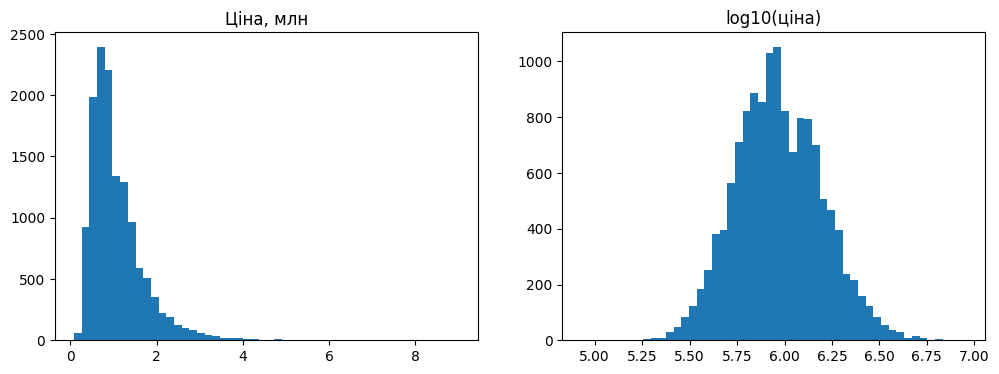

In [340]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(df['Price'] / 1e6, bins=50)
ax[0].set_title("Ціна, млн")
ax[1].hist(np.log10(df['Price']), bins=50)
ax[1].set_title("log10(ціна)")

plt.show()